<a href="https://colab.research.google.com/github/3dgarxx3/Mineria_Datos/blob/main/TercerParcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tercer Parcial

## K‑Nearest Neighbors (K-NN) k vecinos más cercanos

###Ejercicio 1: k‑NN manual (k = 1, distancia euclidiana)

####Datos

In [1]:
import math

# Datos de entrenamiento
X = [(2,4), (4,4), (4,2), (6,2)]
y = ['Rojo', 'Rojo', 'Azul', 'Azul']

# Punto a clasificar
P = (3, 3)

####Función de distancia euclidiana

In [2]:
def distancia_euclidiana(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

####Cálculo del vecino más cercano

In [3]:
distancias = []
for i in range(len(X)):
    d = distancia_euclidiana(P, X[i])
    distancias.append((d, y[i]))

# Ordenar por distancia
distancias.sort(key=lambda x: x[0])

print(distancias)
print("Clase asignada:", distancias[0][1])

[(1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Azul'), (3.1622776601683795, 'Azul')]
Clase asignada: Rojo


###Ejercicio 2: k‑NN manual con k = 3

In [4]:
from collections import Counter

k = 3
vecinos = distancias[:k]

clases = [clase for _, clase in vecinos]
resultado = Counter(clases).most_common(1)

print("Vecinos:", vecinos)
print("Clase asignada:", resultado[0][0])


Vecinos: [(1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Rojo'), (1.4142135623730951, 'Azul')]
Clase asignada: Rojo


### Ejercicio 3: Distancia Manhattan

In [5]:
def distancia_manhattan(p1, p2):
    return abs(p1[0]-p2[0]) + abs(p1[1]-p2[1])

X = [(1,1), (2,3), (5,4), (6,5)]
y = ['Baja', 'Baja', 'Alta', 'Alta']
P = (4,3)

distancias = []

for i in range(len(X)):
    d = distancia_manhattan(P, X[i])
    distancias.append((d, y[i]))

distancias.sort(key=lambda x: x[0])

print(distancias)
print("Clase asignada:", distancias[0][1])

[(2, 'Baja'), (2, 'Alta'), (4, 'Alta'), (5, 'Baja')]
Clase asignada: Baja


###Ejercicio 4: k‑NN con scikit-learn

In [6]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

####Datos tipo Iris (reducido)

In [7]:
X = np.array([
[5.1, 3.5],
[4.9, 3.0],
[6.2, 3.4],
[6.0, 2.9]
])

y = np.array(['Setosa', 'Setosa', 'Versicolor', 'Versicolor'])

P = np.array([[5.8, 3.2]])

####Entrenamiento y predicción

In [8]:
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X, y)

prediccion = modelo.predict(P)
print("Clase predicha:", prediccion[0])

Clase predicha: Versicolor


###Ejercicio K-NN

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Cargar el dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Separación de datos: 80% Entrenamiento, 20% Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Muestras de entrenamiento: {len(X_train)}")
print(f"Muestras de prueba: {len(X_test)}")

Muestras de entrenamiento: 120
Muestras de prueba: 30


####¿Que es el codo?

 es una técnica gráfica utilizada en Machine Learning para encontrar el número óptimo de grupos (k) al usar el algoritmo de agrupamiento K-Means

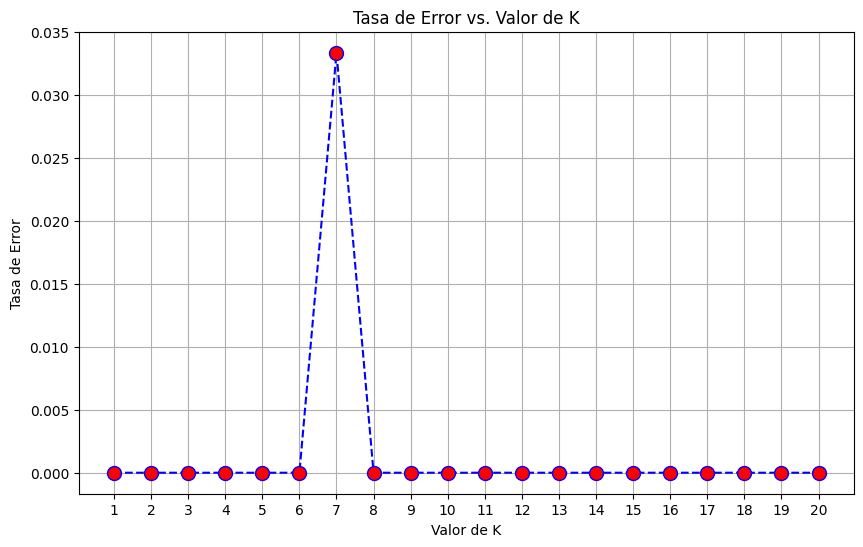

In [ ]:
# Lista para almacenar las tasas de error
error_rate = []

# Probar valores de k del 1 al 20
for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    # Calculamos el promedio de donde la predicción no fue igual al valor real
    error_rate.append(np.mean(pred_i != y_test))

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Tasa de Error vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Tasa de Error')
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

#In-Depth: Decision Trees and Random Forests

In [10]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

##Creación de un árbol de decisión

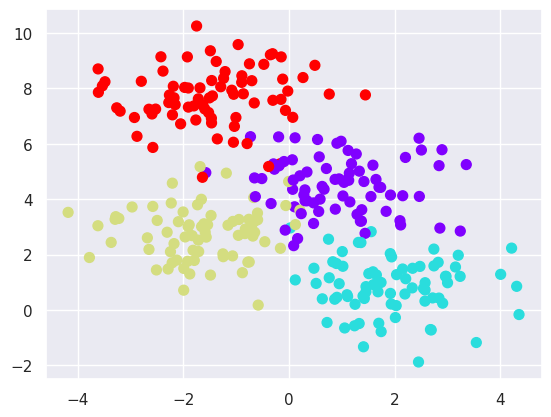

In [11]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');

In [12]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier().fit(X, y)

In [13]:
def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, clim=(y.min(), y.max()),
                           zorder=1)

/tmp/ipykernel_1910/1765752030.py:20: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


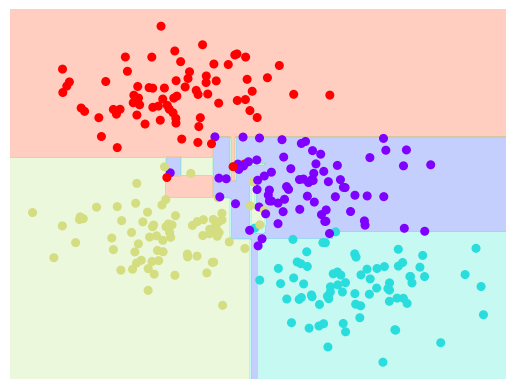

In [14]:
visualize_classifier(DecisionTreeClassifier(), X, y)

##Conjuntos de estimadores: Bosques aleatorios

/tmp/ipykernel_1910/1765752030.py:20: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


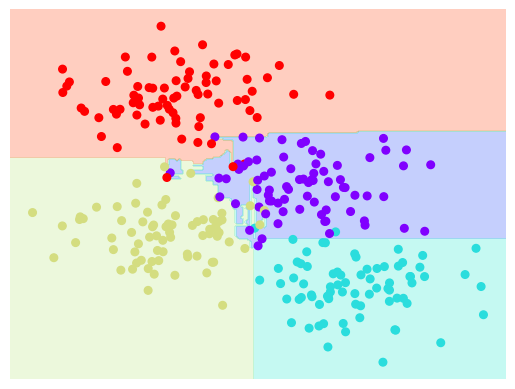

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

tree = DecisionTreeClassifier()
bag = BaggingClassifier(tree, n_estimators=100, max_samples=0.8,
                        random_state=1)

bag.fit(X, y)
visualize_classifier(bag, X, y)

In [16]:
%%file helpers_05_08.py

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from ipywidgets import interact


def visualize_tree(estimator, X, y, boundaries=True,
                   xlim=None, ylim=None, ax=None):
    ax = ax or plt.gca()

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap='viridis',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    if xlim is None:
        xlim = ax.get_xlim()
    if ylim is None:
        ylim = ax.get_ylim()

    # fit the estimator
    estimator.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = estimator.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    n_classes = len(np.unique(y))
    Z = Z.reshape(xx.shape)
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='viridis', clim=(y.min(), y.max()),
                           zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

    # Plot the decision boundaries
    def plot_boundaries(i, xlim, ylim):
        if i >= 0:
            tree = estimator.tree_

            if tree.feature[i] == 0:
                ax.plot([tree.threshold[i], tree.threshold[i]], ylim, '-k', zorder=2)
                plot_boundaries(tree.children_left[i],
                                [xlim[0], tree.threshold[i]], ylim)
                plot_boundaries(tree.children_right[i],
                                [tree.threshold[i], xlim[1]], ylim)

            elif tree.feature[i] == 1:
                ax.plot(xlim, [tree.threshold[i], tree.threshold[i]], '-k', zorder=2)
                plot_boundaries(tree.children_left[i], xlim,
                                [ylim[0], tree.threshold[i]])
                plot_boundaries(tree.children_right[i], xlim,
                                [tree.threshold[i], ylim[1]])

    if boundaries:
        plot_boundaries(0, xlim, ylim)


def plot_tree_interactive(X, y):
    def interactive_tree(depth=5):
        clf = DecisionTreeClassifier(max_depth=depth, random_state=0)
        visualize_tree(clf, X, y)

    return interact(interactive_tree, depth=[1, 5])


def randomized_tree_interactive(X, y):
    N = int(0.75 * X.shape[0])

    xlim = (X[:, 0].min(), X[:, 0].max())
    ylim = (X[:, 1].min(), X[:, 1].max())

    def fit_randomized_tree(random_state=0):
        clf = DecisionTreeClassifier(max_depth=15)
        i = np.arange(len(y))
        rng = np.random.RandomState(random_state)
        rng.shuffle(i)
        visualize_tree(clf, X[i[:N]], y[i[:N]], boundaries=False,
                       xlim=xlim, ylim=ylim)

    interact(fit_randomized_tree, random_state=[0, 100]);

Writing helpers_05_08.py


In [17]:
import importlib
import helpers_05_08
importlib.reload(helpers_05_08)
helpers_05_08.plot_tree_interactive(X, y);

interactive(children=(Dropdown(description='depth', index=1, options=(1, 5), value=5), Output()), _dom_classes…

/tmp/ipykernel_1910/1765752030.py:20: UserWarning: The following kwargs were not used by contour: 'clim'
  contours = ax.contourf(xx, yy, Z, alpha=0.3,


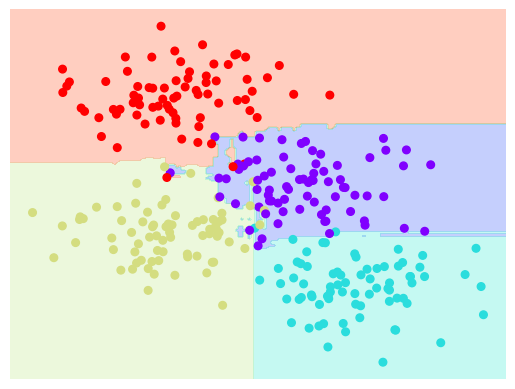

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=0)
visualize_classifier(model, X, y);

##Regresión en bosque aleatorio

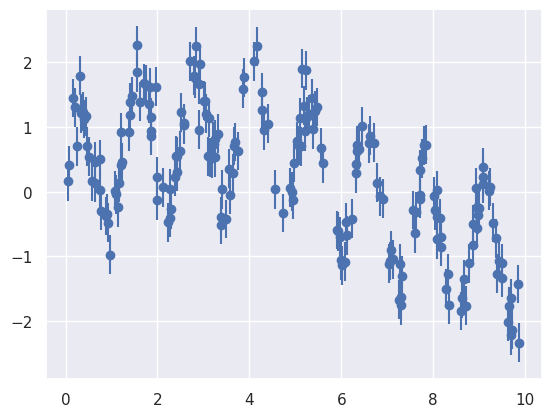

In [19]:
rng = np.random.RandomState(42)
x = 10 * rng.rand(200)

def model(x, sigma=0.3):
    fast_oscillation = np.sin(5 * x)
    slow_oscillation = np.sin(0.5 * x)
    noise = sigma * rng.randn(len(x))

    return slow_oscillation + fast_oscillation + noise

y = model(x)
plt.errorbar(x, y, 0.3, fmt='o');

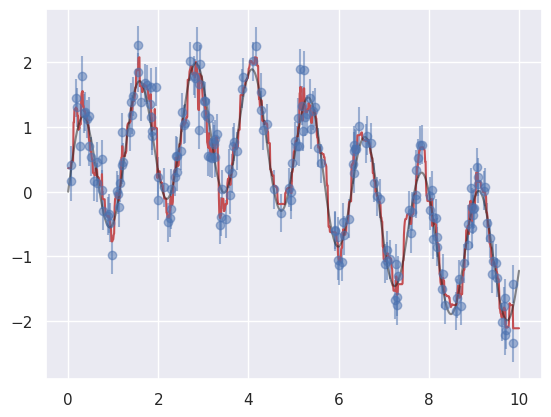

In [20]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor(200)
forest.fit(x[:, None], y)

xfit = np.linspace(0, 10, 1000)
yfit = forest.predict(xfit[:, None])
ytrue = model(xfit, sigma=0)

plt.errorbar(x, y, 0.3, fmt='o', alpha=0.5)
plt.plot(xfit, yfit, '-r');
plt.plot(xfit, ytrue, '-k', alpha=0.5);

##Ejemplo: Random Forest para clasificar dígitos

In [21]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

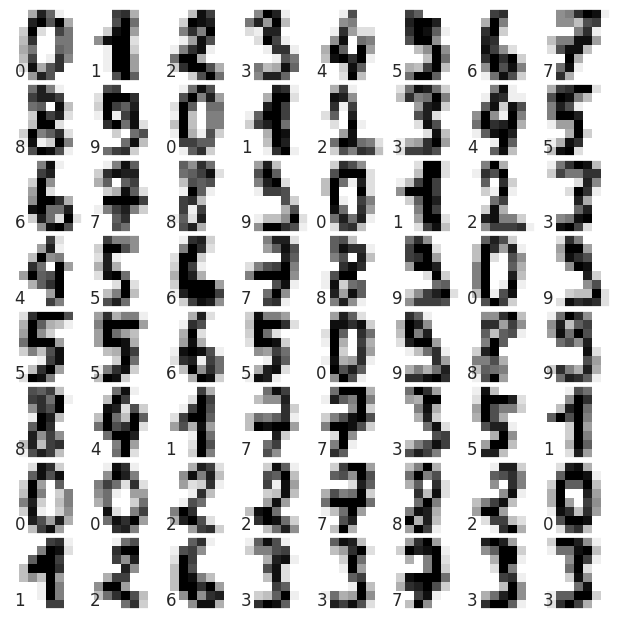

In [22]:
# set up the figure
fig = plt.figure(figsize=(6, 6))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# plot the digits: each image is 8x8 pixels
for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')

    # label the image with the target value
    ax.text(0, 7, str(digits.target[i]))

In [23]:
from sklearn import metrics
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# Load digits data
digits = load_digits()
X = digits.data
y = digits.target

# Split data into training and test sets
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state=0)

# Train Gaussian Naive Bayes model
model = GaussianNB()
model.fit(Xtrain, ytrain)

# Make predictions on the test set
y_model = model.predict(Xtest)

# Print classification report
print(metrics.classification_report(ytest, y_model))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       0.70      0.91      0.79        43
           2       0.95      0.45      0.62        44
           3       0.83      0.87      0.85        45
           4       0.94      0.82      0.87        38
           5       0.98      0.90      0.93        48
           6       1.00      0.98      0.99        52
           7       0.76      0.98      0.85        48
           8       0.55      0.79      0.65        48
           9       1.00      0.64      0.78        47

    accuracy                           0.83       450
   macro avg       0.87      0.83      0.83       450
weighted avg       0.87      0.83      0.83       450



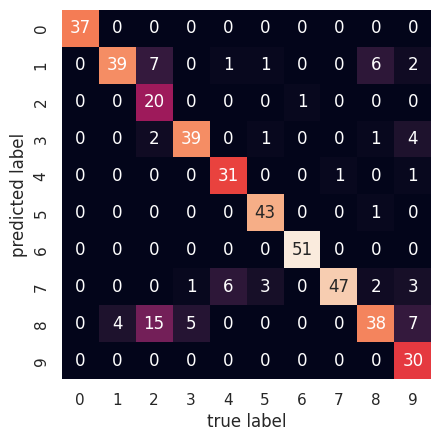

In [24]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, y_model)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('predicted label');

#Ejercicio Liga MX 20/04/2026

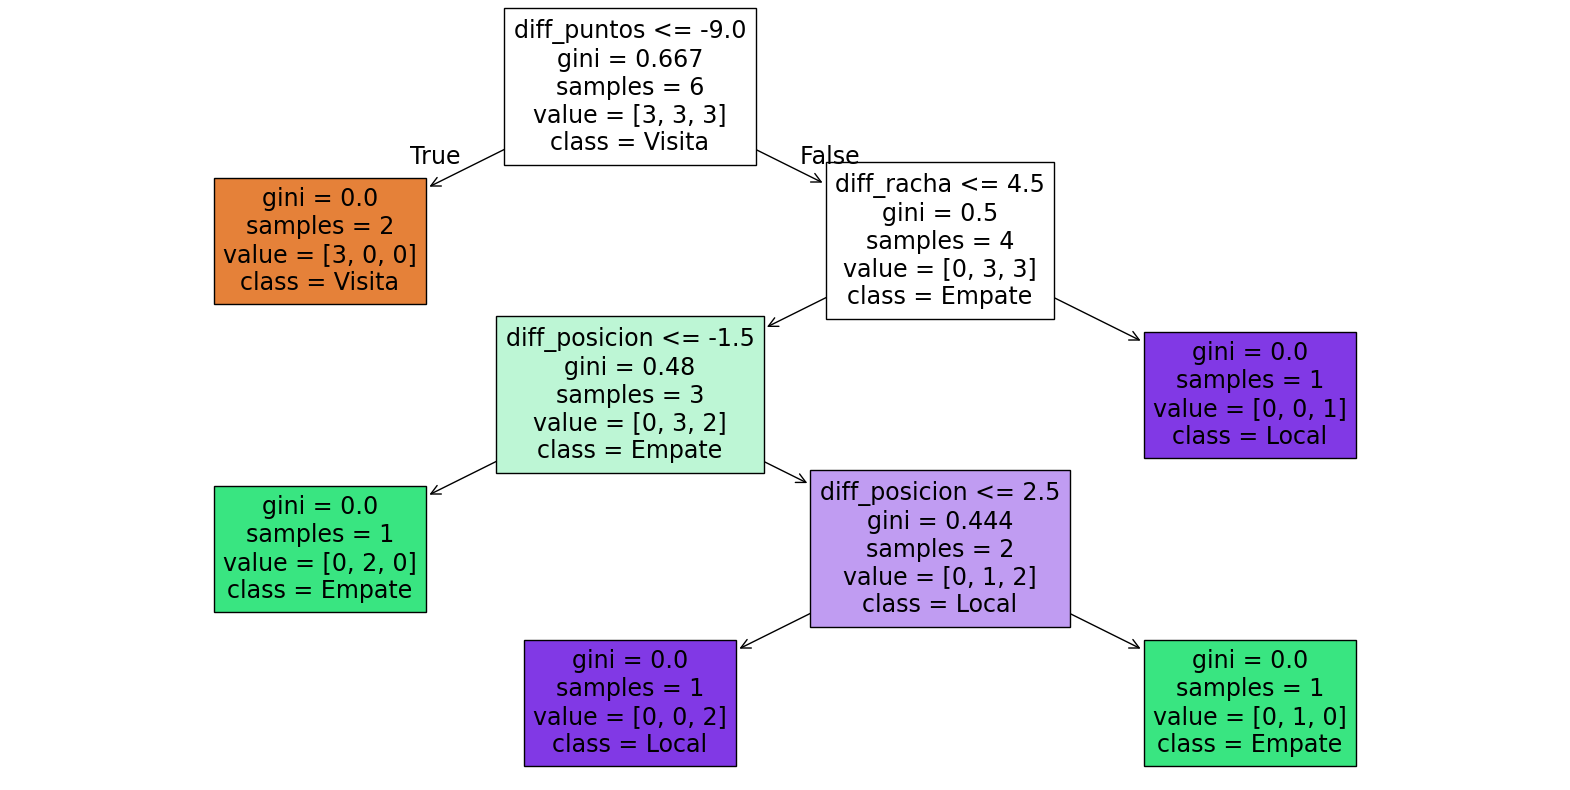

In [ ]:
# Predicción de Resultados de Liga MX con Random Forest

#Libreta didáctica para Google Colab
## Objetivo

#Aplicar Machine Learning supervisado para predecir resultados de partidos de Liga MX usando Random Forest.

import pandas as pd
import numpy as np

## Cargar dataset
df = pd.read_csv('dataset_liga_mx_jornadas_13_14_15_base.csv')
df.head()

## Selección de features
features = ['diff_puntos','diff_racha','diff_posicion']
X = df[features]
y = df['resultado']

## Entrenamiento del Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X, y)

## Importancia de variables
importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values(ascending=False)

## Visualización de un árbol
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0], feature_names=features, class_names=['Visita','Empate','Local'], filled=True)
plt.show()

## Ética y uso responsable
#Este modelo es educativo. No debe usarse para apuestas ni decisiones financieras.

In [ ]:
#diccionario para actualizar los puntos
teams_stats = {}
for idx, row in df[df['jornada'] == 15].iterrows(): #aqui se usa para filtrar la ultima jornada
    pts_l = row['local_puntos']
    racha_l = row['local_racha']
    if row['resultado'] == 2: #gana local
        pts_l += 3
        racha_l += 1
    elif row['resultado'] == 1: #empate
        pts_l += 1
    else: #pierde local
        racha_l = max(0, racha_l - 1)

    teams_stats[row['equipo_local']] = {'puntos': pts_l, 'racha': racha_l}

    pts_v = row['visita_puntos']
    racha_v = row['visita_racha']
    if row['resultado'] == 0: #gana visita
        pts_v += 3
        racha_v += 1
    elif row['resultado'] == 1: #empate
        pts_v += 1
    else: #pierde visita
        racha_v = max(0, racha_v - 1)

    teams_stats[row['equipo_visita']] = {'puntos': pts_v, 'racha': racha_v}

# nueva posición en la tabla con los nuevos puntos del excel
sorted_teams = sorted(teams_stats.keys(), key=lambda x: teams_stats[x]['puntos'], reverse=True)
for i, t in enumerate(sorted_teams):
    teams_stats[t]['posicion'] = i + 1

matches_j16 = [
    ('Querétaro', 'Cruz Azul'),
    ('Pumas', 'FC Juárez'),
    ('Monterrey', 'Puebla'),
    ('León', 'América'),
    ('Atlas', 'Tigres'),
    ('Atlético San Luis', 'Santos'),
    ('Mazatlán', 'Toluca'),
    ('Necaxa', 'Chivas'),
    ('Tijuana', 'Pachuca')
]

print("Predicciones del random forest")
for local, visita in matches_j16:
    stats_l = teams_stats[local]
    stats_v = teams_stats[visita]

    diff_puntos = stats_l['puntos'] - stats_v['puntos']
    diff_racha = stats_l['racha'] - stats_v['racha']
    diff_posicion = stats_v['posicion'] - stats_l['posicion']
    #tabla para guardar puntos
    X_pred = pd.DataFrame([[diff_puntos, diff_racha, diff_posicion]], columns=features)

    #aqui predecimos
    pred = rf.predict(X_pred)[0]

    if pred == 2:
        res = "Gana local"
    elif pred == 1:
        res = "Empatan"
    else:
        res = "Gana visitante"

    print(f"{local} vs {visita}")
    print(f"Predicción: {res}\n")

Predicciones del random forest
Querétaro vs Cruz Azul
Predicción: Gana visitante

Pumas vs FC Juárez
Predicción: Gana local

Monterrey vs Puebla
Predicción: Gana local

León vs América
Predicción: Empatan

Atlas vs Tigres
Predicción: Empatan

Atlético San Luis vs Santos
Predicción: Gana local

Mazatlán vs Toluca
Predicción: Gana visitante

Necaxa vs Chivas
Predicción: Gana visitante

Tijuana vs Pachuca
Predicción: Gana visitante



# In-Depth: Support Vector Machines

In [25]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# use seaborn plotting defaults
import seaborn as sns; sns.set()

##Máquinas de vectores de soporte motivadoras

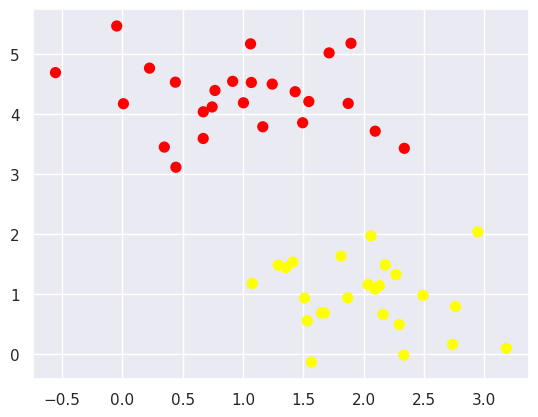

In [26]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

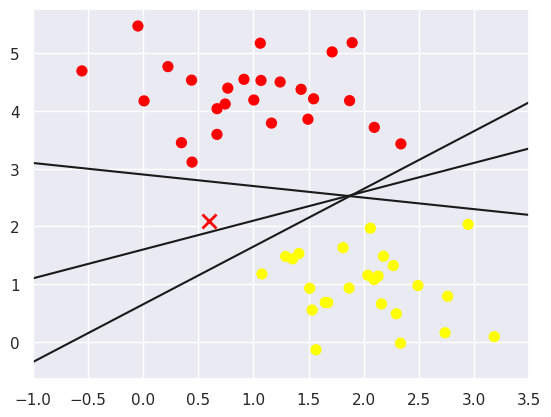

In [27]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)

for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.xlim(-1, 3.5);

##Máquinas de vectores de soporte: Maximizando el margen

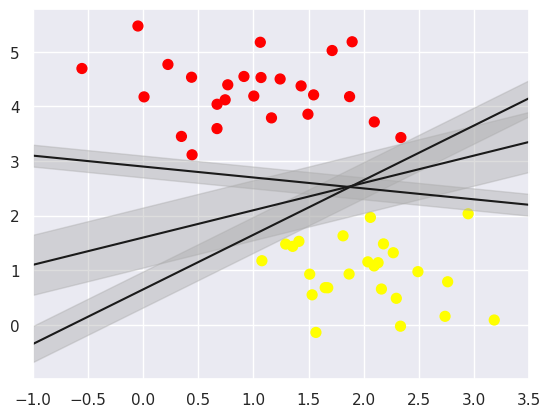

In [28]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5);

##Adaptación de una máquina de vectores de soporte

In [29]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

In [30]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

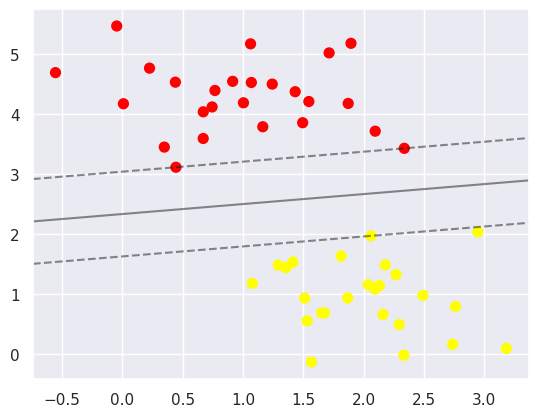

In [31]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model);

In [32]:
model.support_vectors_

array([[0.44359863, 3.11530945],
       [2.33812285, 3.43116792],
       [2.06156753, 1.96918596]])

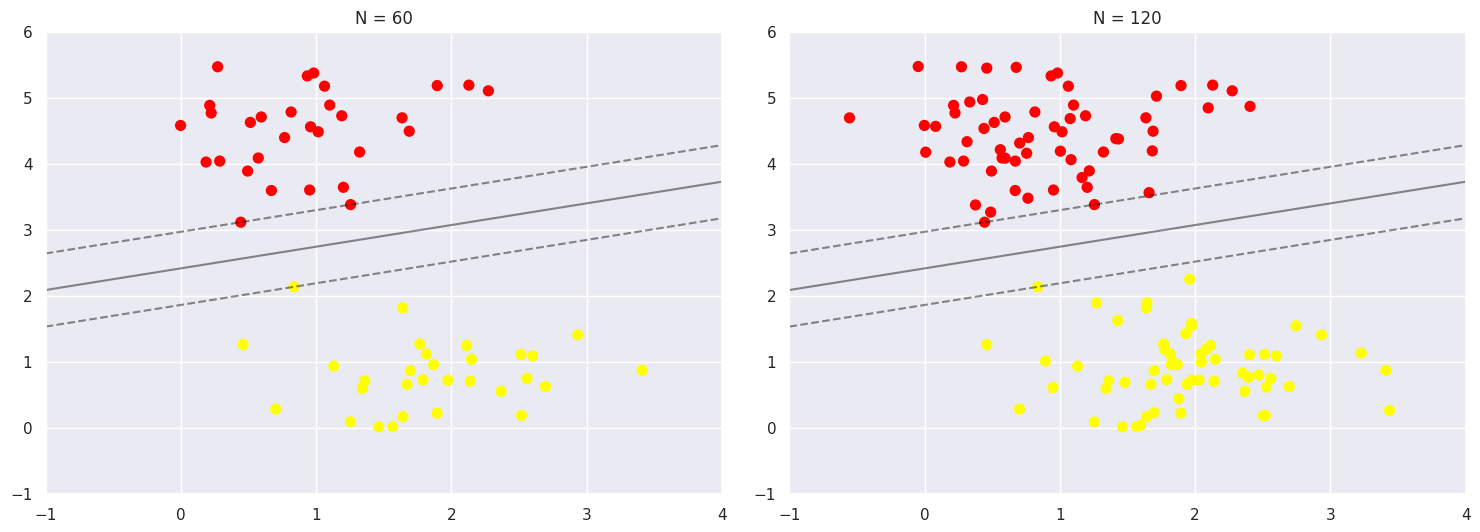

In [33]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

In [34]:
from ipywidgets import interact, fixed
interact(plot_svm, N=[10, 200], ax=fixed(None));

interactive(children=(Dropdown(description='N', options=(10, 200), value=10), Output()), _dom_classes=('widget…

###Más allá de los límites lineales: SVM del núcleo

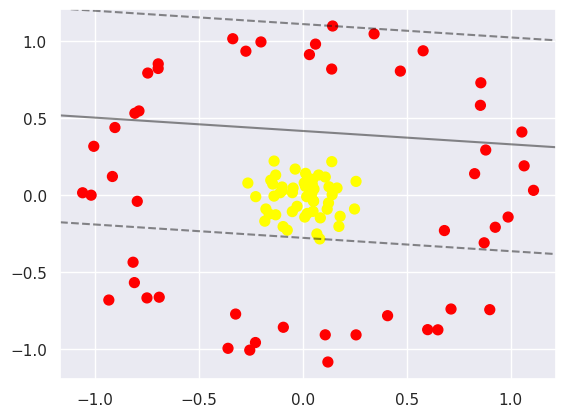

In [35]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

In [36]:
r = np.exp(-(X ** 2).sum(1))

In [37]:
from mpl_toolkits import mplot3d

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 90], azip=(-180, 180),
         X=fixed(X), y=fixed(y));

interactive(children=(Dropdown(description='elev', options=(-90, 90), value=-90), IntSlider(value=30, descript…

In [38]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

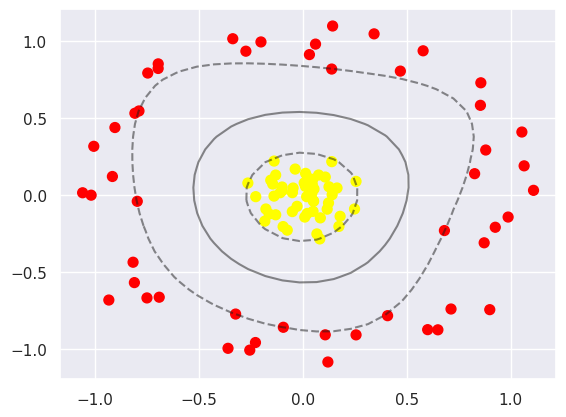

In [39]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none');

####Ajuste del SVM: Suavizando los márgenes

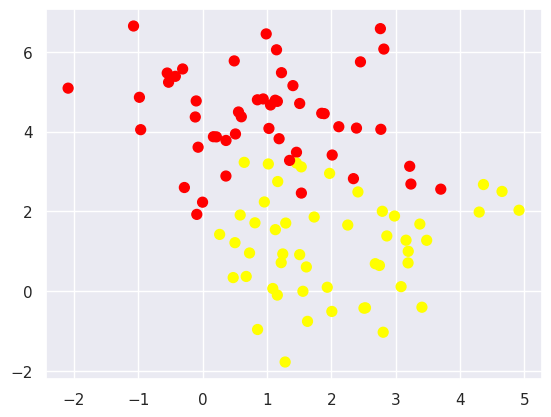

In [40]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

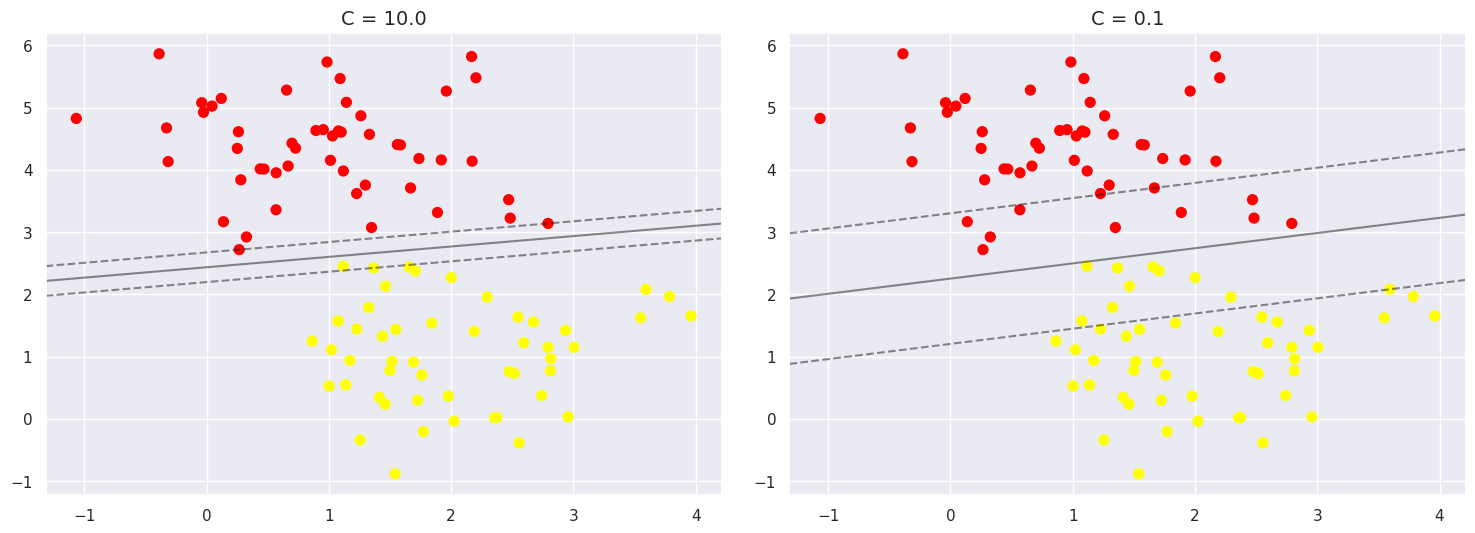

In [41]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

####Ejemplo: reconocimiento facial

In [42]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


In [43]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

pca = PCA(n_components=150, whiten=True, random_state=42, svd_solver='randomized')
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

In [44]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target,
                                                    random_state=42)

In [45]:
model.fit(Xtrain, ytrain)

Pipeline(steps=[('pca',
                 PCA(n_components=150, random_state=42, svd_solver='randomized',
                     whiten=True)),
                ('svc', SVC(class_weight='balanced'))])

In [46]:
yfit = model.predict(Xtest)

In [47]:
from sklearn.metrics import classification_report
print(classification_report(ytest, yfit, target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       1.00      0.73      0.85        15
     Colin Powell       0.69      0.96      0.80        68
  Donald Rumsfeld       0.89      0.77      0.83        31
    George W Bush       0.90      0.87      0.88       126
Gerhard Schroeder       0.89      0.70      0.78        23
      Hugo Chavez       1.00      0.65      0.79        20
Junichiro Koizumi       1.00      0.92      0.96        12
       Tony Blair       0.86      0.86      0.86        42

         accuracy                           0.85       337
        macro avg       0.90      0.81      0.84       337
     weighted avg       0.87      0.85      0.85       337



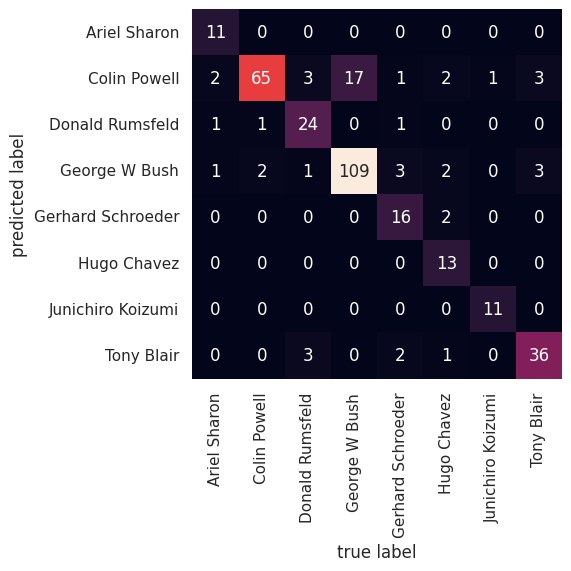

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

##CLASIFICACIÓN DE DÍGITOS MANUSCRITOS

Cargando dataset Digits (8x8)...


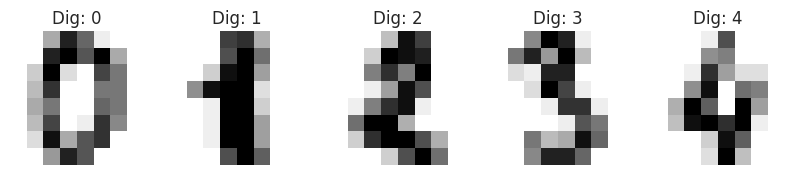


Entrenando modelos...

--- RESULTADOS DE EXACTITUD (ACCURACY) ---
K-NN: 97.50%
SVM: 98.06%
Random Forest: 97.22%

Generando imágenes manuscritas propias...


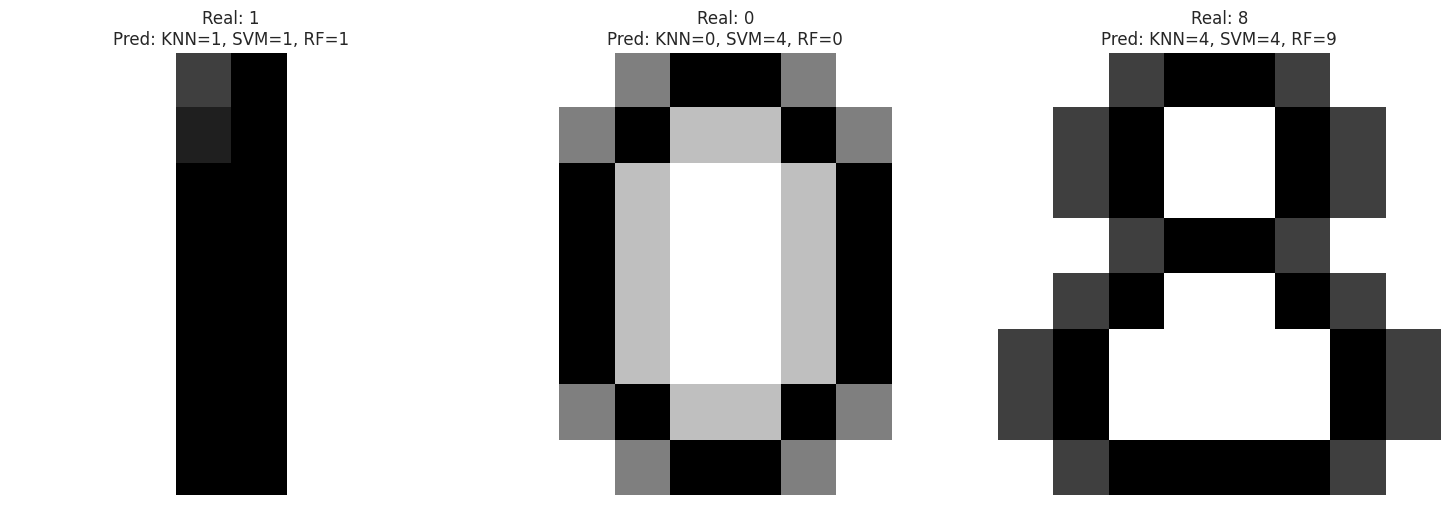

In [50]:
# =================================================================
# ACTIVIDAD: CLASIFICACIÓN DE DÍGITOS MANUSCRITOS
# Modelos: K-NN, SVM y Random Forest
# =================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. CARGA DEL DATASET
print("Cargando dataset Digits (8x8)...")
digits = datasets.load_digits()

# Visualización de muestra
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r)
    ax.set_title(f'Dig: {label}')
plt.show()

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)

# NORMALIZACIÓN (Basado en tu Ejercicio 5: Vital para K-NN y SVM)
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

# 2. ENTRENAMIENTO DE MODELOS
print("\nEntrenando modelos...")

# Modelo 1: K-Nearest Neighbors (k=5, Distancia Euclidiana - Ejercicio 4)
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_norm, y_train)

# Modelo 2: Support Vector Machine (Kernel RBF - Referencia VanderPlas)
svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train_norm, y_train)

# Modelo 3: Random Forest (100 estimadores - Referencia VanderPlas)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_norm, y_train)

# 3. EVALUACIÓN
print("\n--- RESULTADOS DE EXACTITUD (ACCURACY) ---")
modelos = [('K-NN', knn), ('SVM', svm), ('Random Forest', rf)]

for nombre, modelo in modelos:
    acc = accuracy_score(y_test, modelo.predict(X_test_norm))
    print(f"{nombre}: {acc * 100:.2f}%")

# 4. CREACIÓN DE IMÁGENES PROPIAS (Matrices manuales 8x8)
# Nota: Los valores van de 0 (blanco) a 16 (negro)
print("\nGenerando imágenes manuscritas propias...")

img1 = np.array([ # Un "1"
    [0,0,0,12,16,0,0,0],[0,0,0,14,16,0,0,0],[0,0,0,16,16,0,0,0],
    [0,0,0,16,16,0,0,0],[0,0,0,16,16,0,0,0],[0,0,0,16,16,0,0,0],
    [0,0,0,16,16,0,0,0],[0,0,0,16,16,0,0,0]
]).flatten()

img2 = np.array([ # Un "0"
    [0,0,8,16,16,8,0,0],[0,8,16,4,4,16,8,0],[0,16,4,0,0,4,16,0],
    [0,16,4,0,0,4,16,0],[0,16,4,0,0,4,16,0],[0,16,4,0,0,4,16,0],
    [0,8,16,4,4,16,8,0],[0,0,8,16,16,8,0,0]
]).flatten()

img3 = np.array([ # Un "8"
    [0,0,12,16,16,12,0,0],[0,12,16,0,0,16,12,0],[0,12,16,0,0,16,12,0],
    [0,0,12,16,16,12,0,0],[0,12,16,0,0,16,12,0],[12,16,0,0,0,0,16,12],
    [12,16,0,0,0,0,16,12],[0,12,16,16,16,16,12,0]
]).flatten()

mis_imagenes = [img1, img2, img3]
etiquetas_reales = [1, 0, 8]

# 5. PREDICCIÓN Y VISUALIZACIÓN FINAL
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (img, real) in enumerate(zip(mis_imagenes, etiquetas_reales)):
    # Normalizar la imagen propia igual que el set de entrenamiento
    img_norm = scaler.transform([img])

    # Predecir
    p_knn = knn.predict(img_norm)[0]
    p_svm = svm.predict(img_norm)[0]
    p_rf = rf.predict(img_norm)[0]

    axes[i].imshow(img.reshape(8,8), cmap=plt.cm.gray_r)
    axes[i].set_title(f"Real: {real}\nPred: KNN={p_knn}, SVM={p_svm}, RF={p_rf}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()